langchain agents


In [ ]:
import langchain
langchain. __version__

'1.2.7'

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")


In [44]:
from langchain_groq import ChatGroq

# Initialize Groq model
groq_model = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY")
)

In [41]:
def get_weather(city:str)->str:
    """Get the weather for a specific city.
    
    Args:
        city: The name of the city to get weather for
        
    Returns:
        A string describing the weather in the city
    """
    
    return f"weather in {city} is sunny"


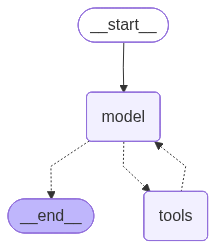

In [45]:
from langchain.agents import create_agent

agent=create_agent(
    model=groq_model,
    tools=[get_weather],
    system_prompt="You are a helpful system agent"
)
agent

In [48]:
agent.invoke({"messages":"what is the weather in delhi"})

{'messages': [HumanMessage(content='what is the weather in delhi', additional_kwargs={}, response_metadata={}, id='acd06a8a-e0b4-40d7-a61d-b09d7c4d0783'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '5ypaw0140', 'function': {'arguments': '{"city":"delhi"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 286, 'total_tokens': 301, 'completion_time': 0.022941217, 'completion_tokens_details': None, 'prompt_time': 0.017154815, 'prompt_tokens_details': None, 'queue_time': 0.050828217, 'total_time': 0.040096032}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c138e-b325-78d2-80de-8e0e0f3b3d49-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'delhi'}, 'id': '5ypaw0140', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_toke

## Test Groq API Key

In [ ]:
from groq import Groq


client = Groq()
message = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": "who are you"}],
        max_tokens=100
    )
print(f"{message} \n")
print(message.choices[0].message.content)



ChatCompletion(id='chatcmpl-824fe174-b355-4e82-aac9-fa031be7c0c0', choices=[Choice(finish_reason='length', index=0, logprobs=None, message=ChatCompletionMessage(content="I'm an artificial intelligence model known as a large language model (LLM) or a conversational AI. I'm a computer program designed to understand and process human language, allowing me to generate human-like responses to a wide range of questions, topics, and conversations.\n\nI'm a type of machine learning model trained on vast amounts of text data, which enables me to learn patterns, relationships, and context within language. This training allows me to:\n\n1. Understand the meaning behind words and phrases.\n", role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1769853038, model='llama-3.1-8b-instant', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_f757f4b0bf', usage=CompletionUsage(completion_token

## Using Google Gemini with LangChain

In [29]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage

# Initialize Gemini model
# gemini_model = ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash-lite",
#     google_api_key=os.getenv("GOOGLE_API_KEY"),
#     temperature=0.7
# )
gemini_model = ChatGoogleGenerativeAI(
    model="gemma-3-27b-it",
    google_api_key=os.getenv("GOOGLE_API_KEY"),
    temperature=0.7
)

# Test with a simple message
message = HumanMessage(content="What is LangChain?")
response = gemini_model.invoke([message])
print("Gemini Response:")
print(response.content)


Gemini Response:
## LangChain: A Deep Dive into the Framework for LLM Applications

LangChain is a powerful framework designed to simplify the development of applications powered by Large Language Models (LLMs) like GPT-3, GPT-4, PaLM 2, and many others. It's essentially a toolkit that helps you build more sophisticated and useful applications than just simple prompts to an LLM.

Here's a breakdown of what LangChain is, its key components, why it's popular, and its use cases:

**What Problem Does LangChain Solve?**

LLMs are amazing at generating text, translating languages, writing different kinds of creative content, and answering your questions in an informative way. However, they have limitations:

* **Limited Context Window:** LLMs can only "remember" a certain amount of text at a time (the context window).  This makes it hard to work with large documents or maintain long conversations.
* **Lack of Real-World Access:** LLMs don't inherently have access to external data sources lik